# Разведочный анализ данных: датасеты чеков CORD и SROIE

Прежде чем дообучать модели, нужно как следует понять данные. В проекте используются два публичных датасета чеков, и они довольно разные по устройству, поэтому разберём каждый отдельно, а потом сравним.

Первый датасет - CORD. Это фотографии кассовых чеков с подробной вложенной разметкой: товарные позиции, их цены и итоговая сумма. У CORD есть изображения, и разработчики Donut уже обучили на нём модель, которая отлично извлекает позиции и сумму. Поэтому CORD мы не обучаем сами, а используем готовую модель на нём как компонент для извлечения позиций.

Второй датасет - SROIE. В нём размечены реквизиты чека: название магазина, дата, адрес и сумма — то, чего нет в CORD и чему готовая модель не обучена. У SROIE есть и изображения чеков, поэтому именно на нём мы дообучаем Donut извлекать реквизиты. Это и есть наш главный обучаемый компонент.

В ходе анализа мы хотим выяснить:

- Насколько полно в каждом датасете размечены ключевые поля: магазин, дата, итоговая сумма.
-   Насколько сложны и разнообразны чеки SROIE: какой длины получается целевая разметка реквизитов и какие у изображений размеры. Эти цифры обоснуют гиперпараметры дообучения Donut.
- В каких форматах записаны суммы и даты, насколько они единообразны. Это нужно для будущего модуля нормализации.
- Нет ли в данных проблем: пустых разметок, выбросов, дубликатов, — которые стоит заметить заранее.

Выводы по каждому разделу мы будем формулировать только после того, как увидим фактические результаты, и в самом конце соберём их в общую картину, которая определит дальнейшие решения по обучению.

## Запуск в Google Colab

Ноутбук рассчитан на запуск в Colab по кнопке **Run all** без ручных скачиваний.
Код и данные подтягиваются с удалённых источников автоматически:

- датасеты **CORD** и **SROIE (текст)** — с HuggingFace Hub (`load_dataset`);
- картинки **SROIE** (`sroie_donut`) — zip-архивом с Google Drive по публичной
  ссылке (скачиваются только если их нет локально).

Перед первым запуском задайте в ячейке ниже `SROIE_DONUT_GDRIVE_ID` (id файла на
Google Drive) и `REPO_URL` (публичный репозиторий с кодом проекта).


In [ ]:
# === Настройка окружения для Colab (локально ничего не делает) ===
import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

# --- Удалённые источники (доступ к файлам на Google Drive: "Все, у кого есть ссылка") ---
SROIE_DONUT_GDRIVE_ID = "10nAlGwwvjI0TLhl0JXusYug_KuqZzvfX"   # zip папки data/processed/sroie_donut
REPO_URL = "https://github.com/USER/Receipt-AI.git"  # публичный репозиторий с кодом
PROJECT_DIR = "Receipt-AI"

if IN_COLAB:
    subprocess.run(
        [sys.executable, "-m", "pip", "-q", "install",
         "datasets", "transformers", "seaborn", "gdown", "pillow-heif"],
        check=False,
    )
    # Код проекта: если src/ ещё нет — клонируем репозиторий и заходим внутрь.
    if not Path("src").exists() and not Path(PROJECT_DIR).exists():
        subprocess.run(["git", "clone", REPO_URL, PROJECT_DIR], check=True)
    if Path(PROJECT_DIR).exists():
        os.chdir(PROJECT_DIR)

print("Colab:", IN_COLAB, "| рабочая папка:", Path.cwd())


def ensure_sroie_donut(root):
    """Гарантирует наличие data/processed/sroie_donut.

    Если датасета нет локально (типичный случай в Colab) — скачивает zip-архив
    с Google Drive по публичной ссылке и распаковывает. Благодаря этому ноутбук
    запускается без ручного скачивания данных.
    """
    target = Path(root) / "data" / "processed" / "sroie_donut"
    if (target / "train" / "metadata.jsonl").exists():
        return target  # уже есть локально — ничего не качаем

    import zipfile
    import gdown

    target.parent.mkdir(parents=True, exist_ok=True)
    zip_path = target.parent / "sroie_donut.zip"
    print("sroie_donut не найден локально — качаю с Google Drive...")
    gdown.download(id=SROIE_DONUT_GDRIVE_ID, output=str(zip_path), quiet=False)
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(target.parent)
    zip_path.unlink()
    print("Готово:", target)
    return target


## Настройка окружения

Подключаем библиотеки, фиксируем генератор случайных чисел для воспроизводимости, задаём единый стиль графиков и создаём папку для сохранения картинок.

In [2]:
import sys
import json
import random
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(root))

seed = 42
random.seed(seed)
np.random.seed(seed)

fig_dir = root / "notebooks" / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

print("Корень проекта:", root)
print("Графики сохраняются в:", fig_dir)

Корень проекта: C:\Users\kseni\PycharmProjects\Receipt-AI
Графики сохраняются в: C:\Users\kseni\PycharmProjects\Receipt-AI\notebooks\figures


In [3]:
def savefig(name):
    plt.tight_layout()
    plt.savefig(fig_dir / f"{name}.png", bbox_inches="tight")

## Загрузка датасетов

Читаем оба датасета из кэша через функции, которые мы вынесли в `src/data/datasets.py`. CORD разбит на обучающую, валидационную и тестовую части, SROIE - на обучающую и тестовую. Дальше в этом разделе разбираем CORD, а SROIE возьмёмся изучать в следующем.

In [4]:
from src.data.datasets import load_cord, load_sroie

cord = load_cord()
sroie = load_sroie()

print("CORD:")
for split in cord:
    print(f"  {split}: {len(cord[split])} чеков")

print("SROIE:")
for split in sroie:
    print(f"  {split}: {len(sroie[split])} чеков")

cord_train = cord["train"]

C:\Users\kseni\PycharmProjects\Receipt-AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CORD:
  train: 800 чеков
  validation: 100 чеков
  test: 100 чеков
SROIE:
  train: 626 чеков
  test: 347 чеков


Посмотрим на один чек CORD: из чего состоит пример и как выглядит само изображение.

Поля примера: ['image', 'ground_truth']
Размер изображения: (864, 1296)


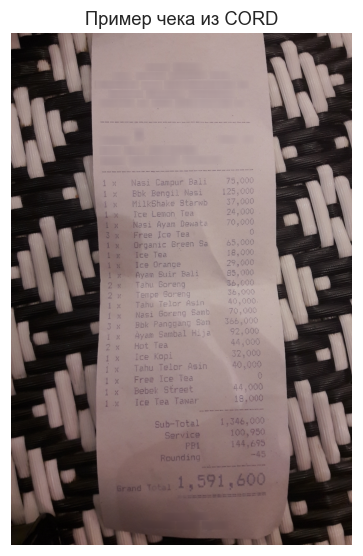

In [5]:
example = cord_train[0]
print("Поля примера:", list(example.keys()))

image = example["image"]
print("Размер изображения:", image.size)

plt.figure(figsize=(4, 8))
plt.imshow(image)
plt.axis("off")
plt.title("Пример чека из CORD")
plt.show()

Разметка лежит в поле `ground_truth` как строка JSON. Внутри неё несколько частей, но главная - это `gt_parse`: именно её модель Donut выдаёт по изображению. Посмотрим, какие ключи есть в разметке и как устроена целевая структура.

In [6]:
gt = json.loads(example["ground_truth"])
print("Ключи ground_truth:", list(gt.keys()))

parse = gt["gt_parse"]
print(json.dumps(parse, ensure_ascii=False, indent=2))

Ключи ground_truth: ['gt_parse', 'meta', 'valid_line', 'roi', 'repeating_symbol', 'dontcare']
{
  "menu": [
    {
      "nm": "Nasi Campur Bali",
      "cnt": "1 x",
      "price": "75,000"
    },
    {
      "nm": "Bbk Bengil Nasi",
      "cnt": "1 x",
      "price": "125,000"
    },
    {
      "nm": "MilkShake Starwb",
      "cnt": "1 x",
      "price": "37,000"
    },
    {
      "nm": "Ice Lemon Tea",
      "cnt": "1 x",
      "price": "24,000"
    },
    {
      "nm": "Nasi Ayam Dewata",
      "cnt": "1 x",
      "price": "70,000"
    },
    {
      "nm": "Free Ice Tea",
      "cnt": "3 x",
      "price": "0"
    },
    {
      "nm": "Organic Green Sa",
      "cnt": "1 x",
      "price": "65,000"
    },
    {
      "nm": "Ice Tea",
      "cnt": "1 x",
      "price": "18,000"
    },
    {
      "nm": "Ice Orange",
      "cnt": "1 x",
      "price": "29,000"
    },
    {
      "nm": "Ayam Suir Bali",
      "cnt": "1 x",
      "price": "85,000"
    },
    {
      "nm": "Tahu Goreng"

По размерам видно, что CORD содержит 1000 чеков (800 на обучение, 100 на валидацию, 100 на тест), а SROIE - 973 чека (626 и 347).

Сам чек в примере - это фотография реального счёта, снятая под небольшим углом, с фоном вокруг. Это хорошо: модель училась не на идеальных сканах, а на таких же снимках, какие потом придут от пользователей.

Разметка `gt_parse` устроена как вложенная структура из трёх частей. Список `menu` - это товарные позиции, у каждой сокращённые ключи: `nm` это название, `cnt` это количество в виде строки вроде `"1 x"`, `price` это цена. Блок `sub_total` хранит промежуточную сумму, сервисный сбор и налог. Блок `total` с ключом `total_price` - итоговую сумму чека.

Также бросаются в глаза сразу две вещи. Во-первых, все числа записаны строками, причём по-разному: разделитель тысяч это запятая (`75,000` означает семьдесят пять тысяч), а у одной позиции в цену затесалась лишняя точка - `"40,000."`. Это прямо показывает, что распознанные суммы нельзя использовать как есть, их придётся нормализовать. Во-вторых, в разметке нет ни названия магазина, ни даты покупки - только позиции и суммы.

In [7]:
print("Содержимое meta:")
print(json.dumps(gt["meta"], ensure_ascii=False, indent=2))
lines = gt["valid_line"]
print("Строк в разметке:", len(lines))

categories = Counter(line["category"] for line in lines)
print("Категории строк:")
for cat, n in categories.most_common():
    print(f"  {cat}: {n}")

Содержимое meta:
{
  "version": "2.0.0",
  "split": "train",
  "image_id": 0,
  "image_size": {
    "width": 864,
    "height": 1296
  }
}
Строк в разметке: 71
Категории строк:
  menu.cnt: 22
  menu.nm: 22
  menu.price: 22
  sub_total.subtotal_price: 1
  sub_total.service_price: 1
  sub_total.tax_price: 1
  sub_total.etc: 1
  total.total_price: 1


Проверка подтвердила то, что было видно по структуре. В блоке meta лежит только служебная информация, а в построчной разметке категории ограничены пунктами меню, подытогами и суммой. Ни магазина, ни даты в CORD нет.

Это определяет роль CORD в проекте. На нём отлично работает готовая модель Donut, обученная авторами, она извлекает товарные позиции и итоговую сумму. Поэтому CORD мы используем не для собственного обучения, а как датасет, на котором проверяем готовую модель и берём её как есть для извлечения позиций. А вот реквизиты, магазин и дату, которых в CORD нет, нам придётся искать в другом датасете. Им станет SROIE, к которому переходим.

## SROIE: структура и разбор

SROIE устроен совсем иначе, чем CORD. Здесь нет готовой вложенной структуры, вместо неё для каждого чека хранится список слов, координаты каждого слова и метка поля, к которому слово относится.

Посмотрим на устройство одного примера: какие поля есть и что в них лежит.

In [8]:
sroie_train = sroie["train"]
ex = sroie_train[0]

print("Поля примера:", list(ex.keys()))
print("Слов в чеке:", len(ex["words"]))
print("Первые 15 слов:", ex["words"][:15])
print("Их теги:", ex["ner_tags"][:15])

Поля примера: ['id', 'words', 'bboxes', 'ner_tags', 'image_path']
Слов в чеке: 89
Первые 15 слов: ['tan', 'woon', 'yann', 'BOOK', 'TA', '_K', '(TAMAN', 'DAYA)', 'SDN', 'BHD', '789417-W', 'NO.5:', '55,57', '&', '59,']
Их теги: [0, 0, 0, 1, 2, 2, 2, 2, 2, 2, 5, 6, 6, 6, 6]


Теги закодированы числами. Чтобы понять, что означает каждое число, посмотрим схему меток самого датасета, она хранится в описании поля `ner_tags`.

In [9]:
print(sroie_train.features["ner_tags"])

List(ClassLabel(names=['O', 'B-COMPANY', 'I-COMPANY', 'B-DATE', 'I-DATE', 'B-ADDRESS', 'I-ADDRESS', 'B-TOTAL', 'I-TOTAL']))


 У каждого чека есть список слов `words`, координаты каждого слова `bboxes`, метки `ner_tags` и путь к картинке `image_path`. Путь, правда, указывает в кэш на сервере, а самих изображений в этой версии датасета нет, поэтому работаем только с текстом.

Метки устроены по схеме BIO, стандартной для разметки именованных сущностей. Каждое слово получает один из девяти тегов. Тег `O` означает, что слово ни к какому полю не относится. Остальные восемь идут парами: префикс `B-` помечает первое слово сущности, префикс `I-` - её продолжение. Сами поля - это COMPANY (магазин), DATE (дата), ADDRESS (адрес) и TOTAL (сумма).

На первом чеке это хорошо видно: слова `tan woon yann` помечены как `O` (это имя получателя, не реквизит), а дальше идёт `BOOK` с тегом 1 (`B-COMPANY`) и `TA _K (TAMAN DAYA) SDN BHD` с тегом 2 (`I-COMPANY`), то есть всё это вместе собирается в одно название магазина. Чтобы из такой разметки получить поле строкой, нужно склеить подряд идущие слова с тегами одной сущности. Ровно это делает функция `decode_sroie_tags`, которую мы вынесли в `src/data/datasets.py`.

In [10]:
from src.data.datasets import decode_sroie_tags

for i in range(3):
    ex = sroie_train[i]
    fields = decode_sroie_tags(ex["words"], ex["ner_tags"])
    print(f"Чек {i}")
    print("  магазин:", fields["company"])
    print("  дата:   ", fields["date"])
    print("  адрес:  ", fields["address"])
    print("  сумма:  ", fields["total"])
    print()

Чек 0
  магазин: BOOK TA _K (TAMAN DAYA) SDN BHD
  дата:    25/12/2018
  адрес:   789417-W NO.5: 55,57 & 59, JALAN SAGU 18, TAMAN DAYA, 81100 JOHOR BAHRU JOHOR.
  сумма:   9.000

Чек 1
  магазин: INDAH GIFT & HOME DECO
  дата:    19/10/2018
  адрес:   27, JALAN DEDAP 13, TAMAN JOHOR JAYA, 81100 JOHOR BAHRU, JOHOR.
  сумма:   60.30

Чек 2
  магазин: MR D.I.Y. (JOHOR) SON BHD
  дата:    12-01-19
  адрес:   LOT 1851-A & 1851-B, JALAN KPB 6, KAWASAN PERINDUSTRIAN BALAKONG, 43300 SERI KEMBANGAN, SELANGOR (MR DIY TESCO TERBAU)
  сумма:   33.90



Декодер уверенно собирает все четыре поля на разных чеках. Магазины, даты, адреса и суммы читаются корректно. Заодно видно то, что осложнит дальнейшую обработку: форматы не унифицированы. Суммы встречаются как 9.000, 60.30, 33.90, даты в разных видах, 25/12/2018 и 12-01-19 с двузначным годом. Эти расхождения придётся приводить к единому виду.

Сравним два датасета по содержанию. CORD, как мы выяснили, размечает товарные позиции и сумму, но не магазин и не дату. SROIE наоборот: в нём есть магазин, дата, адрес и сумма. То есть по набору полей датасеты дополняют друг друга, и вместе покрывают все реквизиты чека, которые нужны.

## Галерея чеков CORD с разметкой

Чтобы посмотреть на данные своими глазами, покажем несколько чеков с наложенной разметкой. Вокруг каждого слова рисуем рамку и раскрашиваем её по типу поля: отдельный цвет для названий позиций, цен, количеств и итоговых сумм. Координаты слов берём из построчной разметки `valid_line`.

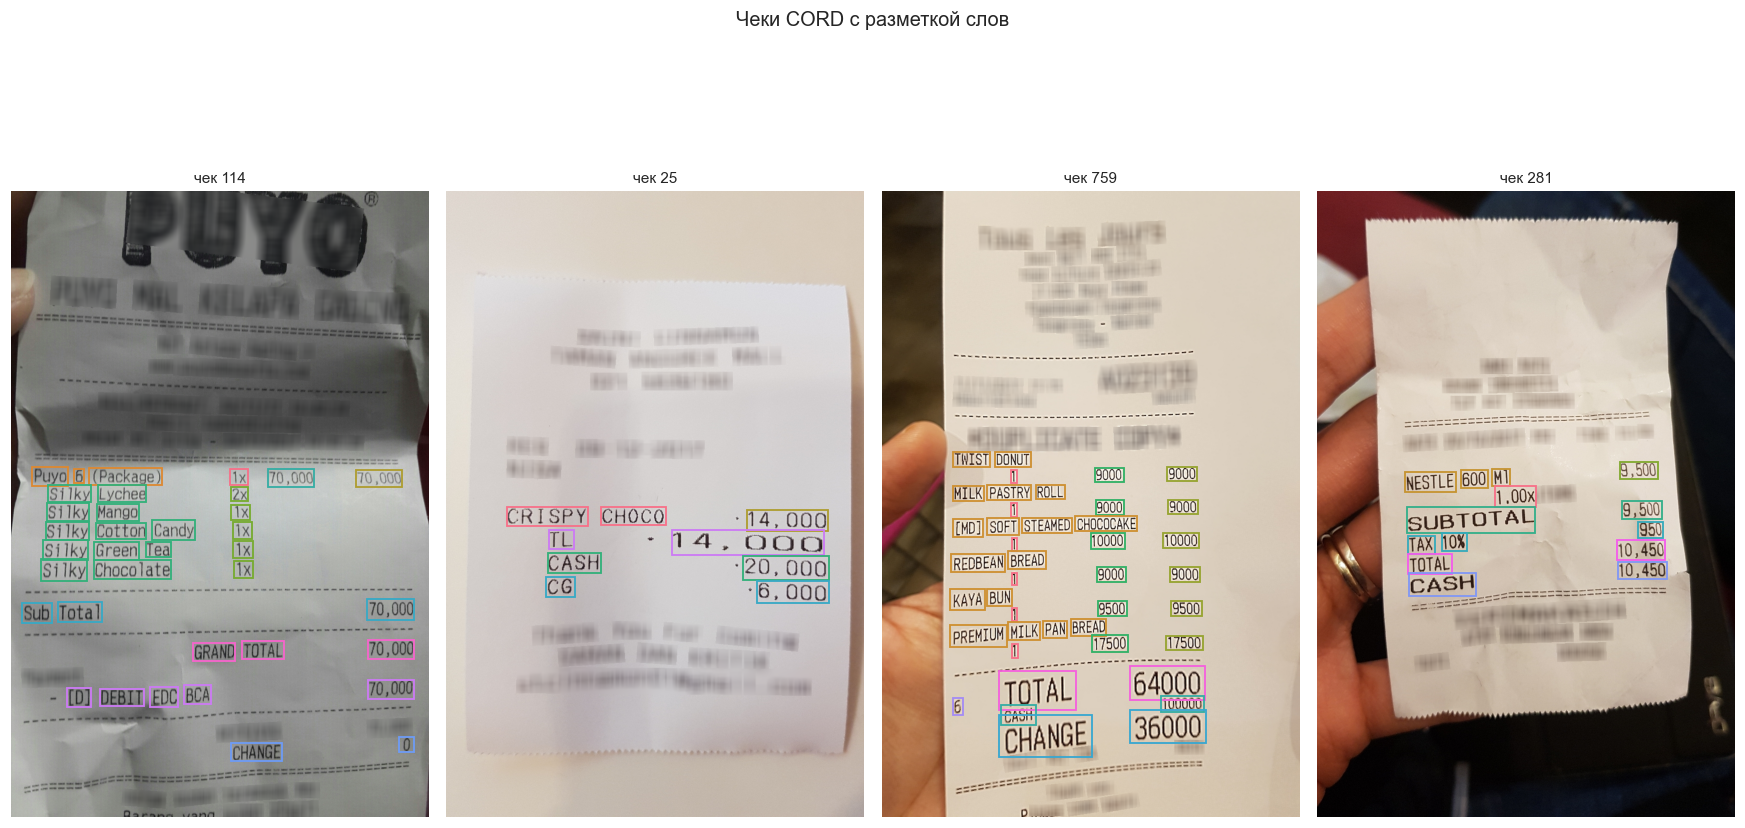

In [11]:
import matplotlib.patches as patches

def draw_annotated(ax, example):
    img = example["image"]
    ax.imshow(img)
    ax.axis("off")
    lines = json.loads(example["ground_truth"])["valid_line"]
    cats = sorted({line["category"] for line in lines})
    palette = dict(zip(cats, sns.color_palette("husl", len(cats))))

    for line in lines:
        color = palette[line["category"]]
        for w in line["words"]:
            q = w["quad"]
            xs = [q["x1"], q["x2"], q["x3"], q["x4"]]
            ys = [q["y1"], q["y2"], q["y3"], q["y4"]]
            x, y = min(xs), min(ys)
            rect = patches.Rectangle((x, y), max(xs) - x, max(ys) - y,
                                     linewidth=1.2, edgecolor=color, facecolor="none")
            ax.add_patch(rect)
    return palette


idx = random.sample(range(len(cord_train)), 4)
fig, axes = plt.subplots(1, 4, figsize=(16, 9))
for ax, i in zip(axes, idx):
    draw_annotated(ax, cord_train[i])
    ax.set_title(f"чек {i}", fontsize=10)
fig.suptitle("Чеки CORD с разметкой слов", fontsize=13)
savefig("cord_annotated_gallery")
plt.show()

Итог сразу показывает, насколько разнородны данные, и это хорошая новость для устойчивости будущей модели. Чеки сняты в совершенно разных условиях. Встречаются перспективные искажения, складки, блики и разный масштаб текста.

По разметке видно ещё одну важную деталь. Рамками покрыты только значимые поля: названия позиций, количества, цены и итоговые блоки. Шапка чека (название магазина, адрес, реквизиты вверху) на многих примерах намеренно размыта и не размечена. Кое-где часть шапки даже заблюрена из соображений приватности.

Для нас отсюда следуют два практических вывода. Во-первых, препроцессинг и аугментации в следующем блоке обязательны: модель должна справляться с наклонами, тенями, изгибами и бликами, потому что именно такие снимки преобладают. Во-вторых, разметка плотная и аккуратная по позициям и суммам, так что для обучения извлечения именно этих полей данные качественные.

## Изображения SROIE

До сих пор мы смотрели на SROIE только как на текст. Но далее я нашла решение как извлечь из датасета картинки, поэтому у нас есть возможность проанализировать и их. Оригинальный датасет SROIE содержит фотографии чеков, которые мы подготовили в отдельную папку. Посмотрим на них внимательно, потому что именно на этих картинках будет учиться модель извлекать реквизиты.

Важно понять, чем эти изображения отличаются от CORD и насколько они пригодны для обучения. Посмотрим на несколько чеков, их типичный вид, качество и разнообразие, а также наложим на них то, что размечено: магазин, дату, адрес и сумму.

In [12]:
import json
from pathlib import Path
from PIL import Image

# Картинок SROIE нет на HuggingFace Hub — это локально подготовленный
# датасет. Если его нет рядом (например, в Colab) — скачиваем с Google Drive.
ensure_sroie_donut(root)
sroie_img_root = root / "data" / "processed" / "sroie_donut" / "train"
sroie_meta = [json.loads(l) for l in
              (sroie_img_root / "metadata.jsonl").read_text(encoding="utf-8").strip().splitlines()]

print("чеков SROIE с картинками в train:", len(sroie_meta))

# размеры нескольких изображений
for ex in sroie_meta[:5]:
    img = Image.open(sroie_img_root / ex["file_name"])
    print(f"{ex['file_name']}: {img.size}")

чеков SROIE с картинками в train: 500
262.jpg: (705, 1276)
313.jpg: (621, 975)
621.jpg: (795, 1705)
075.jpg: (615, 931)
576.jpg: (750, 1471)


Посмотрим на сами чеки. Рядом с каждым выведем то, что для него размечено: магазин, дату, адрес и сумму. Это покажет, насколько разметка соответствует изображению и в каких условиях сняты чеки.

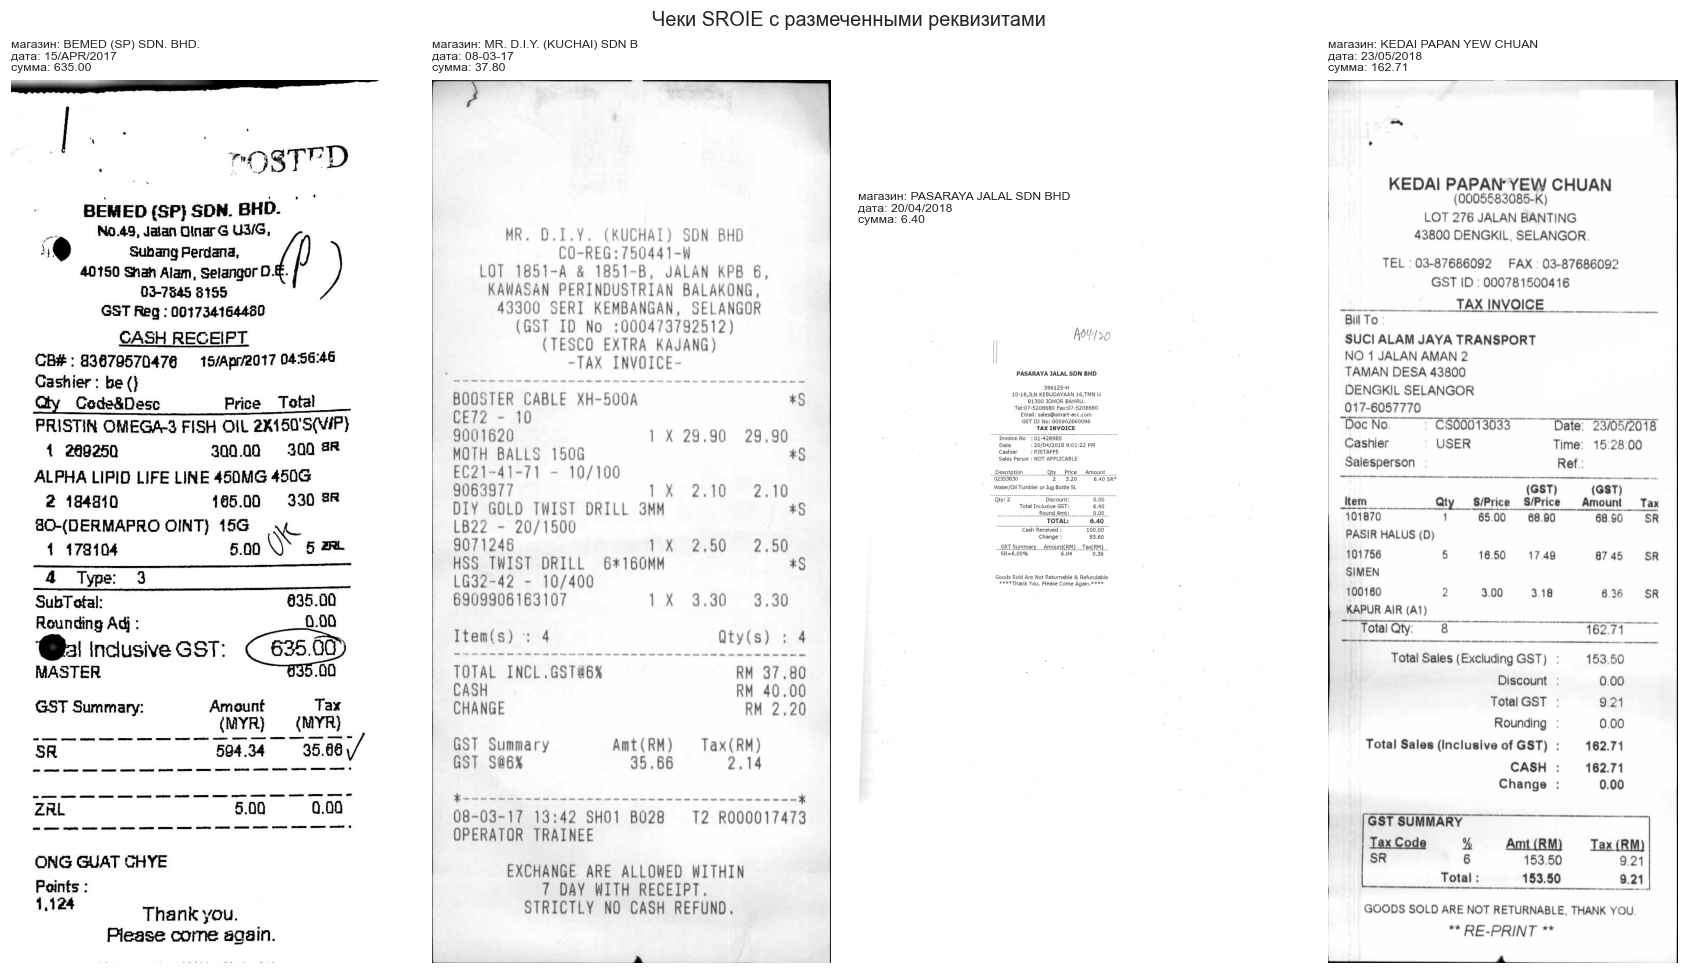

In [13]:
import random
import matplotlib.pyplot as plt

sample = random.sample(sroie_meta, 4)

fig, axes = plt.subplots(1, 4, figsize=(16, 9))
for ax, ex in zip(axes, sample):
    img = Image.open(sroie_img_root / ex["file_name"])
    fields = json.loads(ex["ground_truth"])["gt_parse"]
    ax.imshow(img)
    ax.axis("off")
    caption = (f"магазин: {fields.get('company', '')[:25]}\n"
               f"дата: {fields.get('date', '')}\n"
               f"сумма: {fields.get('total', '')}")
    ax.set_title(caption, fontsize=8, loc="left")
plt.suptitle("Чеки SROIE с размеченными реквизитами", fontsize=13)
plt.tight_layout()
plt.show()

Галерея сразу показывает, чем SROIE отличается от CORD. Чеки SROIE это сканы, а не фотографии. Они плоские, чёрно-белые, сняты ровно, без перспективных искажений, теней и фона. Качество разное: один чек чистый и контрастный, другой бледный и плохо пропечатанный, как третий пример, где текст еле виден. Но геометрически они простые, в отличие от CORD, где чеки сфотографированы под углом на разном фоне.

 Магазин это название вверху чека. Видно и почему сумму извлекать труднее, чем магазин: на чеке много чисел, и итоговая сумма, стоит среди подытогов, налогов, сдачи и цен позиций. Магазин же всегда один и всегда вверху.

Это отличие сканов от фотографий объясняет, почему в нашей системе разумно разделение труда. Детектор и выравнивание перспективы, которые мы обучили на фотографиях, нужны для реальных снимков от пользователя. А модель извлечения реквизитов мы дообучаем на сканах SROIE, где геометрия простая и можно сосредоточиться на распознавании полей, а не на борьбе с искажениями. В реальном пайплайне сначала отработают детектор и выравнивание, приводя фотографию пользователя к ровному виду, похожему на скан, а уже потом модель извлечения возьмёт реквизиты.

## Полнота ключевых полей

Главный вопрос анализа: в какой доле чеков реально размечены ключевые поля.

Считаем полноту отдельно по каждому датасету, потому что структуры у них разные. Для SROIE используем уже готовый декодер. Для CORD напишем разбор структуры `gt_parse`: магазин и дата в нём, как мы выяснили, отсутствуют, сумма лежит в `total.total_price`, позиции - в списке `menu`.

In [27]:
def extract_cord_fields(example):
    parse = json.loads(example["ground_truth"])["gt_parse"]
    menu = parse.get("menu", [])
    if isinstance(menu, dict):
        menu = [menu]
    total = parse.get("total", {})
    return {
        "merchant": None,
        "date": None,
        "total": total.get("total_price") if isinstance(total, dict) else None,
        "num_items": len(menu),
    }


def field_completeness(records, keys):
    n = len(records)
    return {k: sum(1 for r in records if r.get(k)) / n for k in keys}


cord_records = [extract_cord_fields(cord_train[i]) for i in range(len(cord_train))]
sroie_records = [decode_sroie_tags(sroie_train[i]["words"], sroie_train[i]["ner_tags"])
                 for i in range(len(sroie_train))]
cord_compl = field_completeness(cord_records, ["merchant", "date", "total"])
cord_compl["items"] = sum(1 for r in cord_records if r["num_items"] > 0) / len(cord_records)
sroie_compl = field_completeness(sroie_records, ["company", "date", "total"])

print("Полнота полей CORD:")
for k, v in cord_compl.items():
    print(f"  {k:10s}: {v:.1%}")

print("Полнота полей SROIE:")
for k, v in sroie_compl.items():
    print(f"  {k:10s}: {v:.1%}")

Полнота полей CORD:
  merchant  : 0.0%
  date      : 0.0%
  total     : 97.4%
  items     : 100.0%
Полнота полей SROIE:
  company   : 100.0%
  date      : 100.0%
  total     : 100.0%


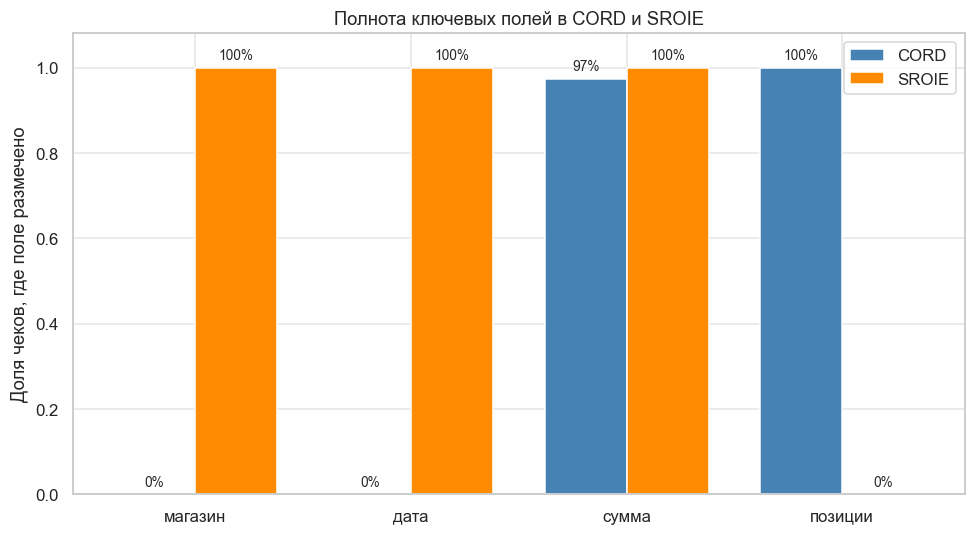

In [28]:
fields = ["merchant", "date", "total", "items"]
labels = ["магазин", "дата", "сумма", "позиции"]
cord_vals = [cord_compl["merchant"], cord_compl["date"], cord_compl["total"], cord_compl["items"]]
sroie_vals = [sroie_compl["company"], sroie_compl["date"], sroie_compl["total"], 0.0]

x = np.arange(len(fields))
width = 0.38
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width / 2, cord_vals, width, label="CORD", color="steelblue")
ax.bar(x + width / 2, sroie_vals, width, label="SROIE", color="darkorange")

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.08)
ax.set_ylabel("Доля чеков, где поле размечено")
ax.set_title("Полнота ключевых полей в CORD и SROIE")
ax.legend()

for i, (c, s) in enumerate(zip(cord_vals, sroie_vals)):
    ax.text(i - width / 2, c + 0.02, f"{c:.0%}", ha="center", fontsize=9)
    ax.text(i + width / 2, s + 0.02, f"{s:.0%}", ha="center", fontsize=9)

savefig("field_completeness_comparison")
plt.show()

График показывает, почему в проекте нужны оба датасета.

CORD силён в содержимом чека: товарные позиции размечены во всех чеках до единого (100%), итоговая сумма почти во всех (97.4%). Но магазина и даты в нём нет вообще.

SROIE, наоборот, силён в реквизитах: магазин, дата и сумма размечены в каждом чеке (100%). Зато товарных позиций он не выделяет совсем.

Стоит отметить, что 100% полнота в SROIE отчасти следствие того, как он устроен: датасет специально размечался под эти четыре поля, поэтому чеки без них в него просто не попали. У сумм в CORD недостающие 2.6% - это чеки, где итог по какой-то причине не выделен отдельной строкой, такие случаи позже стоит проверить в разделе про качество данных.

## Сколько позиций в чеке

Число товарных позиций в CORD показывает, насколько сложны эти чеки. Хотя сами мы CORD не обучаем, полезно понимать сложность данных, на которых работает готовая модель извлечения позиций.

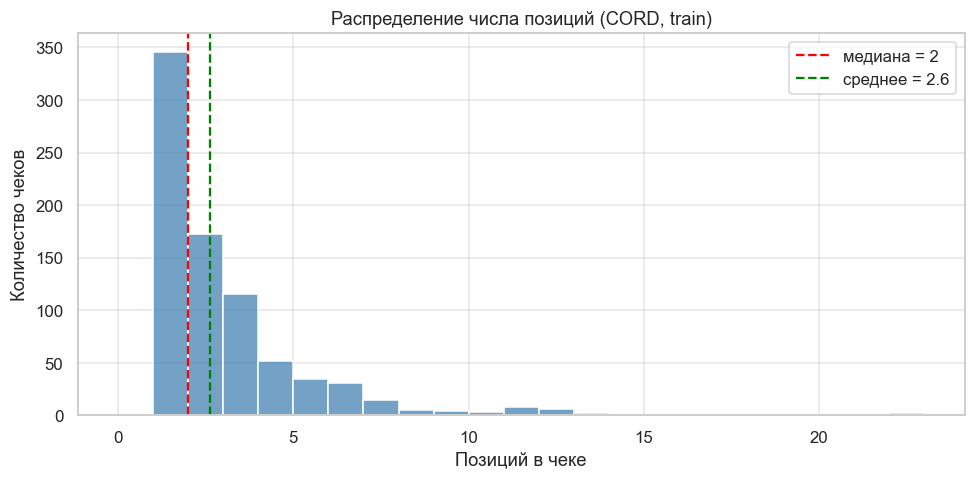

минимум: 1
медиана: 2
среднее: 2.6
95-й перцентиль: 7
максимум: 22


In [29]:
num_items = [r["num_items"] for r in cord_records]

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(num_items, bins=range(0, max(num_items) + 2), color="steelblue", ax=ax)
ax.axvline(np.median(num_items), color="red", ls="--",
           label=f"медиана = {np.median(num_items):.0f}")
ax.axvline(np.mean(num_items), color="green", ls="--",
           label=f"среднее = {np.mean(num_items):.1f}")
ax.set_xlabel("Позиций в чеке")
ax.set_ylabel("Количество чеков")
ax.set_title("Распределение числа позиций (CORD, train)")
ax.legend()
savefig("cord_items_distribution")
plt.show()

print(f"минимум: {min(num_items)}")
print(f"медиана: {np.median(num_items):.0f}")
print(f"среднее: {np.mean(num_items):.1f}")
print(f"95-й перцентиль: {np.percentile(num_items, 95):.0f}")
print(f"максимум: {max(num_items)}")

Распределение сильно смещено влево, с длинным правым хвостом. Большинство чеков короткие: медиана 2 позиции, в среднем 2.6. 95% чеков укладываются в семь позиций, дальше редкий хвост до 22 позиций. Это значит, что готовой модели в большинстве случаев приходится извлекать короткую структуру, но изредка встречаются длинные чеки. Перекос в сторону коротких чеков стоит держать в уме при оценке: средняя метрика в основном отражает работу на простых чеках.

## Суммы и их форматы

Итоговая сумма есть в обоих датасетах, и это удобный повод сравнить, как по-разному записаны числа. Сначала посмотрим на распределение самих сумм, а затем отдельно разберём форматы записи, т.к. именно они определят, насколько сложным должен быть модуль нормализации.

Суммы хранятся строками, поэтому их нужно распарсить в числа. Напишем аккуратный парсер, который убирает всё лишнее и приводит строку к числу с плавающей точкой, и сразу посчитаем, какую долю сумм вообще удаётся распарсить наивным способом.

In [31]:
import re


def parse_amount(raw):
    if not raw:
        return None
    s = re.sub(r"[^\d.,]", "", str(raw))
    if not s:
        return None
    # Последний разделитель считаем десятичным, остальное - разряды
    s = s.replace(",", ".")
    parts = s.split(".")
    if len(parts) > 1:
        s = "".join(parts[:-1]) + "." + parts[-1]
    try:
        return float(s)
    except ValueError:
        return None


cord_totals_raw = [r["total"] for r in cord_records if r["total"]]
sroie_totals_raw = [r["total"] for r in sroie_records if r["total"]]
cord_totals = [parse_amount(x) for x in cord_totals_raw]
sroie_totals = [parse_amount(x) for x in sroie_totals_raw]
cord_ok = sum(1 for x in cord_totals if x is not None) / len(cord_totals)
sroie_ok = sum(1 for x in sroie_totals if x is not None) / len(sroie_totals)

print(f"CORD: распаршено {cord_ok:.1%} сумм")
print(f"SROIE: распаршено {sroie_ok:.1%} сумм")
print("\nПримеры сырых сумм CORD: ", cord_totals_raw[:8])
print("Примеры сырых сумм SROIE:", sroie_totals_raw[:8])

CORD: распаршено 100.0% сумм
SROIE: распаршено 100.0% сумм

Примеры сырых сумм CORD:  ['1,591,600', '580,965', '334,000', '302,016', '48.000', '261,333', '61,799', '36,300']
Примеры сырых сумм SROIE: ['9.000', '60.30', '33.90', '80.90', '30.90', '31.00', '327.00', '20.00']


In [35]:
samples = ["1,591,600", "580,965", "48.000", "9.000", "60.30", "33.90"]
print(f"{'строка':>12}  {'парсер':>15}")
for s in samples:
    print(f"{s:>12}  {parse_amount(s):>15.2f}")

      строка           парсер
   1,591,600          1591.60
     580,965           580.97
      48.000            48.00
       9.000             9.00
       60.30            60.30
       33.90            33.90


In [36]:
suspicious = [(raw, parse_amount(raw)) for raw in cord_totals_raw
              if parse_amount(raw) is not None and parse_amount(raw) < 1000]
print(f"Сумм CORD с результатом < 1000 после парсинга: {len(suspicious)} из {len(cord_totals_raw)}")
print("Примеры (сырое -> распарсено):")
for raw, val in suspicious[:12]:
    print(f"  {raw!r:>14} -> {val}")

Сумм CORD с результатом < 1000 после парсинга: 707 из 779
Примеры (сырое -> распарсено):
       '580,965' -> 580.965
       '334,000' -> 334.0
       '302,016' -> 302.016
        '48.000' -> 48.0
       '261,333' -> 261.333
        '61,799' -> 61.799
        '36,300' -> 36.3
        '36.000' -> 36.0
        '40.000' -> 40.0
        '25.000' -> 25.0
       '250,107' -> 250.107
        '96,000' -> 96.0


Здксь есть интересное наблюдение. Парсер формально распарсил все суммы без единой ошибки, но по сути исказил 707 из 779 сумм CORD. Причина в разной локализации чисел. В индонезийских чеках CORD и точка, и запятая служат разделителями тысяч, а дробной части нет вовсе: `580,965` это пятьсот восемьдесят тысяч рупий, `48.000` это сорок восемь тысяч. В малайзийских чеках SROIE точка - это десятичный разделитель: `60.30` это действительно 60.3 ринггита.

Один и тот же символ означает в двух датасетах противоположные вещи. Парсер, который слепо считает последний разделитель десятичным, верно обрабатывает SROIE и ломает CORD, занижая суммы в тысячу раз. Поймать такое можно только глядя на сами числа, что мы и сделали.

 Модуль нормализации сумм не может применять единое правило ко всем чекам. Он должен учитывать формат источника: для данных в индонезийской локали трактовать точку и запятую как разделители разрядов, для малайзийской - точку как десятичный разделитель.

Чтобы корректно построить распределения ниже, заведём два отдельных парсера под каждую локаль.

In [41]:
def parse_amount_id(raw):
    # Индонезийская локаль (CORD)
    if not raw:
        return None
    digits = re.sub(r"[^\d]", "", str(raw))
    return int(digits) if digits else None


def parse_amount_my(raw):
    # Малайзийская локаль (SROIE)
    if not raw:
        return None
    s = re.sub(r"[^\d.]", "", str(raw).replace(",", ""))
    try:
        return float(s)
    except ValueError:
        return None


cord_amounts = [v for v in (parse_amount_id(x) for x in cord_totals_raw) if v]
sroie_amounts = [v for v in (parse_amount_my(x) for x in sroie_totals_raw) if v]
print("CORD:")
print(f"  медиана: {np.median(cord_amounts):,.0f}")
print(f"  диапазон: {min(cord_amounts):,} .. {max(cord_amounts):,}")
print("SROIE:")
print(f"  медиана: {np.median(sroie_amounts):,.2f}")
print(f"  диапазон: {min(sroie_amounts):,.2f} .. {max(sroie_amounts):,.2f}")

CORD:
  медиана: 49,000
  диапазон: 3,100 .. 5,583,455,800
SROIE:
  медиана: 27.10
  диапазон: 1.00 .. 7,185,111.90


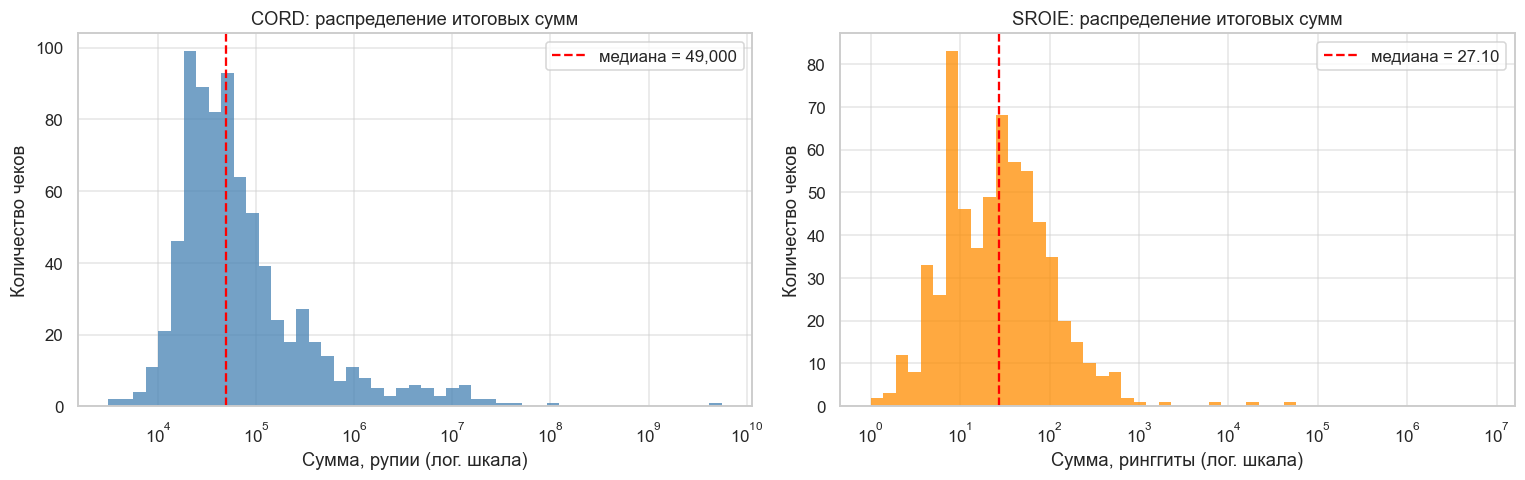

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

cord_bins = np.logspace(np.log10(min(cord_amounts)), np.log10(max(cord_amounts)), 50)
sns.histplot(cord_amounts, bins=cord_bins, color="steelblue", ax=axes[0])
axes[0].set_xscale("log")
axes[0].axvline(np.median(cord_amounts), color="red", ls="--",
                label=f"медиана = {np.median(cord_amounts):,.0f}")
axes[0].set_xlabel("Сумма, рупии (лог. шкала)")
axes[0].set_ylabel("Количество чеков")
axes[0].set_title("CORD: распределение итоговых сумм")
axes[0].legend()

sroie_bins = np.logspace(np.log10(min(sroie_amounts)), np.log10(max(sroie_amounts)), 50)
sns.histplot(sroie_amounts, bins=sroie_bins, color="darkorange", ax=axes[1])
axes[1].set_xscale("log")
axes[1].axvline(np.median(sroie_amounts), color="red", ls="--",
                label=f"медиана = {np.median(sroie_amounts):,.2f}")
axes[1].set_xlabel("Сумма, ринггиты (лог. шкала)")
axes[1].set_ylabel("Количество чеков")
axes[1].set_title("SROIE: распределение итоговых сумм")
axes[1].legend()

savefig("amounts_distribution")
plt.show()

На логарифмической шкале распределения сумм в обоих датасетах выглядят похоже: основная масса чеков сосредоточена вокруг медианы. При этом в обоих датасетах видны явные выбросы. В CORD максимум достигает 5.5 миллиардов рупий, в SROIE - 7 миллионов ринггитов. Это нереалистичные для чеков значения, почти наверняка артефакты: либо ошибка в разметке, либо несколько чисел, слипшихся при распознавании в одно. Сами по себе они единичны и общую картину не определяют, но их полезно пометить и отдельно посмотреть в разделе про качество данных, а при обучении иметь в виду, что подобные выбросы стоит отфильтровывать.

## Длина последовательности и выбор max_length

При дообучении Donut модель генерирует разметку как последовательность токенов, и у генерации есть предел длины - параметр max_length. Слишком маленький порог обрежет длинные чеки, слишком большой впустую расходует память. Посмотрим на реальную длину целевых строк SROIE, чтобы выбрать порог.

In [14]:
from transformers import DonutProcessor

processor = DonutProcessor.from_pretrained("naver-clova-ix/donut-base-finetuned-cord-v2")
tokenizer = processor.tokenizer

field_order = ["company", "date", "address", "total"]

def sroie_target(gt):
    parts = ["<s_sroie>"]
    for f in field_order:
        parts.append(f"<s_{f}>{gt.get(f, '')}</s_{f}>")
    parts.append("</s>")
    return "".join(parts)

sroie_lengths = []
for ex in sroie_meta:
    gt = json.loads(ex["ground_truth"])["gt_parse"]
    n = len(tokenizer(sroie_target(gt), add_special_tokens=False)["input_ids"])
    sroie_lengths.append(n)

sroie_lengths = np.array(sroie_lengths)
print(f"медиана: {np.median(sroie_lengths):.0f}")
print(f"95-й перцентиль: {np.percentile(sroie_lengths, 95):.0f}")
print(f"99-й перцентиль: {np.percentile(sroie_lengths, 99):.0f}")
print(f"максимум: {sroie_lengths.max()}")

медиана: 95
95-й перцентиль: 111
99-й перцентиль: 116
максимум: 127


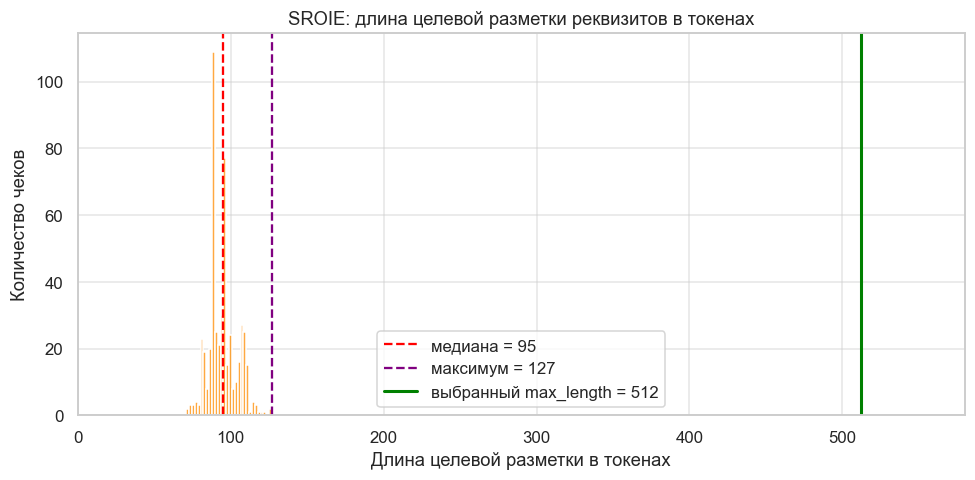

In [20]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(sroie_lengths, bins=30, color="darkorange", ax=ax)
ax.axvline(np.median(sroie_lengths), color="red", ls="--",
           label=f"медиана = {np.median(sroie_lengths):.0f}")
ax.axvline(sroie_lengths.max(), color="purple", ls="--",
           label=f"максимум = {sroie_lengths.max()}")
ax.axvline(512, color="green", ls="-", linewidth=2,
           label="выбранный max_length = 512")
ax.set_xlim(0, 580)
ax.set_xlabel("Длина целевой разметки в токенах")
ax.set_ylabel("Количество чеков")
ax.set_title("SROIE: длина целевой разметки реквизитов в токенах")
ax.legend()
savefig("sroie_token_length")
plt.show()

Целевые строки реквизитов короткие: медиана 95 токенов, максимум 127. Это закономерно для четырёх полей.

В качестве максимальной длины последовательности при дообучении выбрано значение 512 токенов. Этот выбор соответствует эталонной методике дообучения Donut на датасете SROIE, описанной в материалах Hugging Face (туториал philschmid, document-ai-transformers), где для той же задачи используется max_length 512. Значение заведомо покрывает фактический максимум в 127 токенов, исключая обрезание любого чека. Поскольку max_length задаёт верхнюю границу генерации и при превышении длины данных не влияет на качество, использование стандартного для этой задачи значения обеспечивает совместимость с моделью без какого-либо ущерба.

## Разрешения и ориентация изображений

Donut приводит любое входное изображение к фиксированному размеру, заданному в конфиге параметром `image_size`. Если этот размер плохо соответствует реальным пропорциям чеков, картинки будут сильно искажаться или терять детали при масштабировании. Чеки обычно сильно вытянуты по вертикали, и нам нужно убедиться, что заданный размер это учитывает.

In [18]:
from PIL import Image

ws, hs = [], []
for ex in sroie_meta:
    img = Image.open(sroie_img_root / ex["file_name"])
    ws.append(img.width)
    hs.append(img.height)

ws, hs = np.array(ws), np.array(hs)
aspect = hs / ws

print("ширина медиана:", int(np.median(ws)))
print("высота медиана:", int(np.median(hs)))
print("соотношение h/w медиана:", round(float(np.median(aspect)), 2))
print("соотношение диапазон:", round(float(aspect.min()), 2), "..", round(float(aspect.max()), 2))

ширина медиана: 813
высота медиана: 1688
соотношение h/w медиана: 1.99
соотношение диапазон: 1.31 .. 3.8


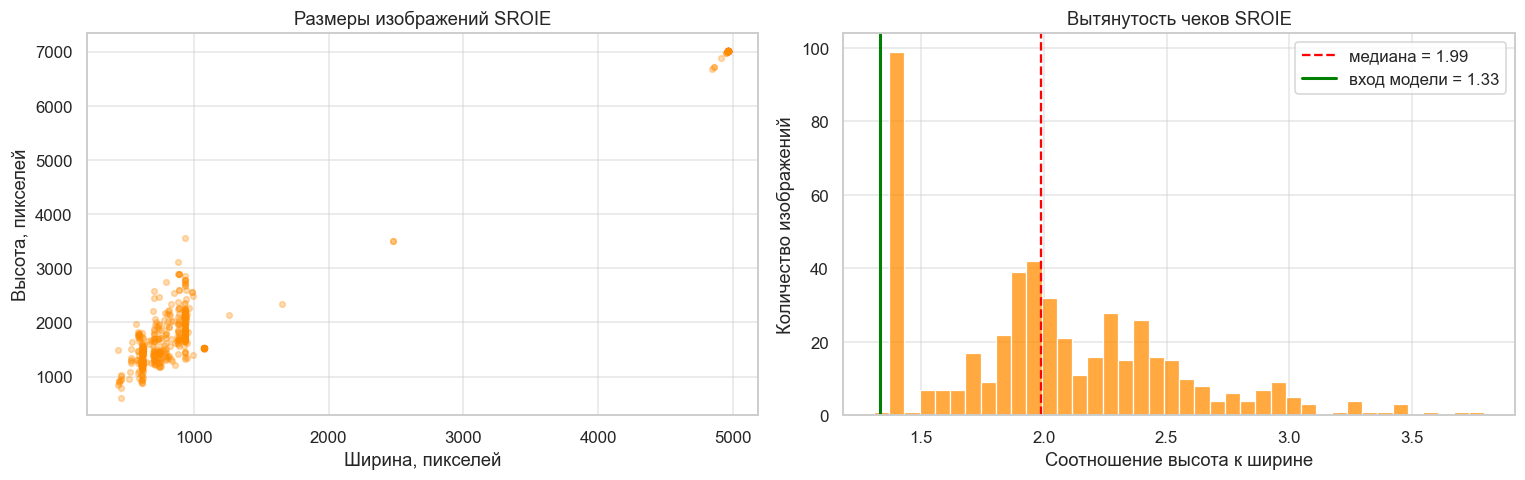

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].scatter(ws, hs, alpha=0.3, s=14, color="darkorange")
axes[0].set_xlabel("Ширина, пикселей")
axes[0].set_ylabel("Высота, пикселей")
axes[0].set_title("Размеры изображений SROIE")

sns.histplot(aspect, bins=40, color="darkorange", ax=axes[1])
axes[1].axvline(np.median(aspect), color="red", ls="--",
                label=f"медиана = {np.median(aspect):.2f}")
axes[1].axvline(1280/960, color="green", ls="-", linewidth=2,
                label=f"вход модели = {1280/960:.2f}")
axes[1].set_xlabel("Соотношение высота к ширине")
axes[1].set_ylabel("Количество изображений")
axes[1].set_title("Вытянутость чеков SROIE")
axes[1].legend()

savefig("sroie_image_sizes")
plt.show()

Чеки SROIE сильно вытянуты по вертикали: медианное соотношение высоты к ширине почти 2 к 1, а у части чеков доходит до 3.8. Это длинные узкие сканы, что естественно для кассовых чеков с большим числом строк. Медианный размер около 813 на 1688 пикселей.

При дообучении вход модели мы оставили родным, 1280 на 960, то есть соотношение примерно 1.33. Видно, что это заметно менее вытянуто, чем реальные чеки SROIE с их соотношением около 2. При приведении чека к входу модели он сжимается по высоте, и текст становится плотнее. Тем не менее мы сознательно не меняли размер входа: у предобученного Donut веса энкодера привязаны к исходному разрешению, и его изменение потребовало бы переинициализации части весов и более долгого обучения, что на наших небольших данных рискованно.

## Текст и язык чеков

Понимание языка и лексики данных нужно по двум причинам. Во-первых, категоризатор в дальнейшем будет определять тип траты по названию магазина и позициям, и ему важно, на каком языке этот текст. Во-вторых, надо трезво оценить, насколько модель, обученная на этих данных, перенесётся на русскоязычные чеки.

Соберём самые частые слова отдельно по каждому датасету. Для CORD возьмём названия позиций из структуры, для SROIE весь распознанный текст. Совсем короткие токены и чистые числа отбросим, они не несут смысла для оценки языка.

In [53]:
import re


def words_from_text(text):
    if isinstance(text, list):
        text = " ".join(str(t) for t in text)
    tokens = re.findall(r"[A-Za-z]{3,}", str(text).lower())
    return tokens


cord_words = Counter()
for i in range(len(cord_train)):
    parse = json.loads(cord_train[i]["ground_truth"])["gt_parse"]
    menu = parse.get("menu", [])
    if isinstance(menu, dict):
        menu = [menu]
    for item in menu:
        cord_words.update(words_from_text(item.get("nm", "")))

sroie_words = Counter()
for i in range(len(sroie_train)):
    sroie_words.update(words_from_text(" ".join(sroie_train[i]["words"])))

print("CORD, частые слова в названиях позиций:")
for w, n in cord_words.most_common(15):
    print(f"{w}: {n}")

print()
print("SROIE, частые слова в тексте чеков:")
for w, n in sroie_words.most_common(15):
    print(f"{w}: {n}")

CORD, частые слова в названиях позиций:
tea: 113
cheese: 77
nasi: 73
choco: 69
ayam: 57
teh: 48
chicken: 47
iced: 44
goreng: 42
bread: 41
mineral: 39
ice: 37
bag: 35
cream: 35
putih: 33

SROIE, частые слова в тексте чеков:
gst: 2251
total: 1904
tax: 1236
cash: 716
invoice: 712
amount: 634
jalan: 600
qty: 501
you: 454
bhd: 450
change: 443
thank: 435
summary: 422
date: 391
item: 374


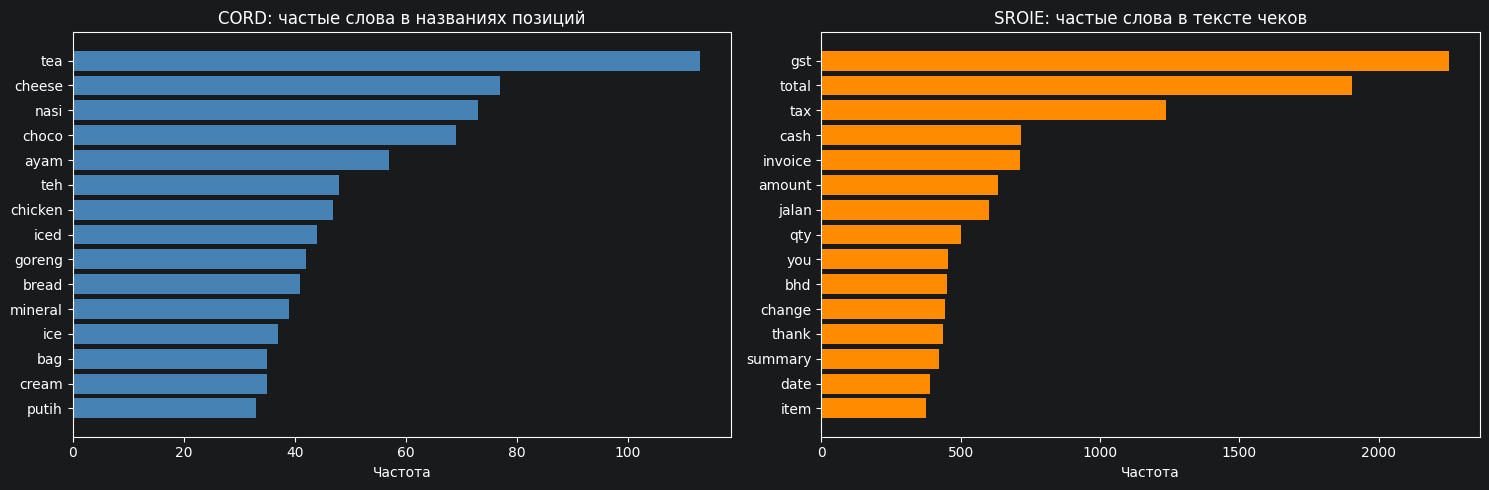

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

cw = cord_words.most_common(15)[::-1]
axes[0].barh([w for w, _ in cw], [n for _, n in cw], color="steelblue")
axes[0].set_title("CORD: частые слова в названиях позиций")
axes[0].set_xlabel("Частота")
sw = sroie_words.most_common(15)[::-1]
axes[1].barh([w for w, _ in sw], [n for _, n in sw], color="darkorange")
axes[1].set_title("SROIE: частые слова в тексте чеков")
axes[1].set_xlabel("Частота")
savefig("frequent_words")
plt.show()

Два датасета хорошо различаются по характеру текста. В CORD частые слова это названия еды и напитков: tea, cheese, choco, chicken, bread, cream, а рядом индонезийские и яванские слова nasi (рис), ayam (курица), teh (чай), goreng (жареное), putih (белый). Это подтверждает, что CORD состоит в основном из чеков общепита и кафе, а язык смешанный.

В SROIE частые слова совсем другие. Это служебная лексика самого чека: gst и tax (налог), total, amount, cash, change, invoice, qty, date, а также bhd и jalan. Здесь видно, что разметка покрывает весь чек целиком, а не только позиции, и язык малайзийско-английский. Слова thank you тоже частые, это типичная подпись в конце чека.

Для проекта отсюда два вывода. Категоризатор будет работать с преимущественно англоязычной и индонезийско-малайзийской лексикой, поэтому многоязычная модель BERT здесь оправдана: она понимает разные языки и не привязана к одному. Что касается переносимости на русские чеки, нужно быть реалистами. Модель, обученная только на этих данных, русскую лексику видеть не будет, поэтому из коробки на русских чеках она сработает слабо.

## Прикидка категорий трат

В дальнейшем категоризатор будет относить каждый чек к одной из шести категорий: продукты, кафе и рестораны, транспорт, аптека, развлечения и прочее. Сейчас, на этапе анализа, у нас нет готовой разметки категорий ни в одном датасете. Но полезно заранее прикинуть, насколько эти категории вообще различимы по тексту чека и не окажется ли так, что почти всё свалится в одну кучу.

Сделаем грубую разметку по ключевым словам: если в тексте чека встречаются характерные слова, относим его к соответствующей категории. Это намеренно примитивный подход, и важно понимать его ограничения. Это не настоящая разметка и не способ обучения, а только оценка осуществимости. Реальную разметку категорий мы подготовим отдельно в блоке про категоризатор. Здесь же цель одна: понять, есть ли в данных вообще сигнал для разделения на категории и насколько сильным будет перекос.

In [55]:
rules = {
    "Продукты": ["mart", "market", "grocery", "supermarket", "fresh", "mini", "store"],
    "Кафе и рестораны": ["cafe", "coffee", "resto", "restaurant", "kitchen", "tea", "nasi",
                          "ayam", "food", "bakery", "bread", "choco", "milk"],
    "Транспорт": ["taxi", "grab", "fuel", "petrol", "gas", "parking", "transport", "toll"],
    "Аптека": ["pharma", "pharmacy", "guardian", "watson", "clinic", "medic", "drug"],
    "Развлечения": ["cinema", "movie", "game", "karaoke", "ticket", "park", "entertain"],
}


def rough_category(text):
    low = text.lower()
    for cat, kws in rules.items():
        if any(k in low for k in kws):
            return cat
    return "Прочее"


cord_cats = Counter()
for i in range(len(cord_train)):
    parse = json.loads(cord_train[i]["ground_truth"])["gt_parse"]
    menu = parse.get("menu", [])
    if isinstance(menu, dict):
        menu = [menu]
    names = " ".join(str(item.get("nm", "")) for item in menu)
    cord_cats[rough_category(names)] += 1

sroie_cats = Counter()
for i in range(len(sroie_train)):
    text = " ".join(sroie_train[i]["words"])
    sroie_cats[rough_category(text)] += 1

order = ["Продукты", "Кафе и рестораны", "Транспорт", "Аптека", "Развлечения", "Прочее"]
print("CORD:")
for c in order:
    print(f"{c}: {cord_cats.get(c, 0)}")
print()
print("SROIE:")
for c in order:
    print(f"{c}: {sroie_cats.get(c, 0)}")

CORD:
Продукты: 14
Кафе и рестораны: 269
Транспорт: 0
Аптека: 1
Развлечения: 1
Прочее: 515

SROIE:
Продукты: 128
Кафе и рестораны: 146
Транспорт: 37
Аптека: 8
Развлечения: 5
Прочее: 302


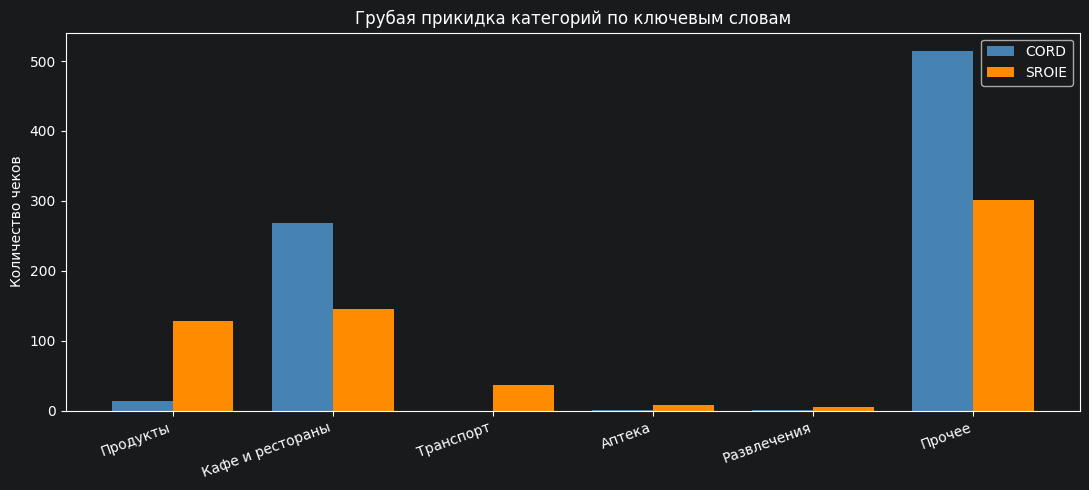

In [56]:
x = np.arange(len(order))
width = 0.38

cord_vals = [cord_cats.get(c, 0) for c in order]
sroie_vals = [sroie_cats.get(c, 0) for c in order]

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width / 2, cord_vals, width, label="CORD", color="steelblue")
ax.bar(x + width / 2, sroie_vals, width, label="SROIE", color="darkorange")
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=20, ha="right")
ax.set_ylabel("Количество чеков")
ax.set_title("Грубая прикидка категорий по ключевым словам")
ax.legend()
savefig("rough_categories")
plt.show()

Распределение показывает две вещи, и обе важны для планирования категоризатора.

Первое: сигнал для разделения категорий в данных есть, но он очень неравномерный. В CORD ожидаемо доминируют кафе и рестораны, потому что это датасет общепита, а транспорт и развлечения почти не представлены. В SROIE категории распределены шире, заметно больше продуктовых магазинов и даже немного транспорта, что логично для разнородного набора розничных чеков. То есть два датасета и по категориям дополняют друг друга: вместе они покрывают больше типов трат, чем каждый по отдельности.

Второе и более серьёзное: огромная доля чеков попала в категорию прочее, 515 из 800 в CORD и 302 из 626 в SROIE. Это прямое следствие примитивности нашего правила. Если магазин называется аббревиатурой или редким словом, которого нет в списке ключевых слов, чек автоматически уходит в прочее, хотя на деле относится к понятной категории. Реальную картину это завышает в сторону прочего.

Отсюда выводы для блока категоризатора. Нельзя обучать модель на такой автоматической разметке напрямую, иначе она просто выучит отвечать прочее в половине случаев. Категории сильно несбалансированы: транспорт, аптека и развлечения представлены единицами примеров, и на них модели почти не на чем учиться. Это значит, что для категоризатора понадобится либо аккуратная ручная разметка хотя бы небольшого качественного набора, либо продуманная стратегия работы с дисбалансом классов, например взвешивание.

## Проверка качества данных

Любая модель чувствительна к мусору в обучающих данных, поэтому перед обучением полезно собрать в одном месте подозрительные случаи. Проверим несколько вещей: нет ли чеков с пустой разметкой, есть ли выбросы по суммам (мы уже видели нереалистичные миллиарды), встречаются ли дубликаты и как много чеков остаётся вовсе без ключевых полей.

In [57]:
# Пустые или вырожденные чеки
cord_empty = sum(1 for r in cord_records if r["num_items"] == 0 and not r["total"])
sroie_empty = sum(1 for r in sroie_records
                  if not any([r["company"], r["date"], r["total"]]))
print("CORD, чеков без позиций и без суммы:", cord_empty)
print("SROIE, чеков без единого поля:", sroie_empty)

# Выбросы по суммам (используем корректные парсеры из раздела 7)
cord_outliers = [parse_amount_id(r["total"]) for r in cord_records if r["total"]]
cord_outliers = [v for v in cord_outliers if v and v > 100_000_000]
sroie_outliers = [parse_amount_my(r["total"]) for r in sroie_records if r["total"]]
sroie_outliers = [v for v in sroie_outliers if v and v > 100_000]
print("\nCORD, сумм больше 100 млн рупий (подозрительные):", len(cord_outliers))
print("примеры:", sorted(cord_outliers, reverse=True)[:5])
print("SROIE, сумм больше 100 тыс ринггитов (подозрительные):", len(sroie_outliers))
print("примеры:", sorted(sroie_outliers, reverse=True)[:5])

CORD, чеков без позиций и без суммы: 0
SROIE, чеков без единого поля: 0

CORD, сумм больше 100 млн рупий (подозрительные): 1
примеры: [5583455800]
SROIE, сумм больше 100 тыс ринггитов (подозрительные): 1
примеры: [7185111.9]


In [58]:
# Дубликаты: одинаковые названия магазинов в SROIE и одинаковый текст
sroie_companies = [r["company"] for r in sroie_records if r["company"]]
dup_companies = Counter(sroie_companies)
print("SROIE, топ повторяющихся магазинов:")
for name, n in dup_companies.most_common(5):
    print(f"{n} раз: {name}")

# Полные дубли текста чека
sroie_texts = [r["text"] for r in sroie_records]
text_dups = sum(1 for _, n in Counter(sroie_texts).items() if n > 1)
print("\nSROIE, полностью совпадающих текстов чеков:", text_dups)

SROIE, топ повторяющихся магазинов:
42 раз: UNIHAKKA INTERNATIONAL SDN BHD
31 раз: SANYU STATIONERY SHOP
30 раз: GARDENIA BAKERIES (KL) SDN BHD
27 раз: RESTORAN WAN SHENG
25 раз: 99 SPEED MART S/B

SROIE, полностью совпадающих текстов чеков: 5


Проверка показала, что серьёзных проблем нет.

Вырожденных чеков не нашлось вовсе: в CORD нет ни одного чека без позиций и без суммы одновременно, в SROIE нет ни одного чека без единого размеченного поля. Это подтверждает высокую полноту, которую мы видели в разделе про поля.

Выбросов по суммам ровно по одному в каждом датасете: 5.5 миллиарда рупий в CORD и 7 миллионов ринггитов в SROIE. Это нереалистичные значения, артефакты разметки или распознавания. Их всего два на почти полторы тысячи чеков, но при подсчёте метрик их стоит отфильтровать, чтобы единичная ошибка не искажала средние.

Повторяющиеся магазины в SROIE это не дубликаты, а норма: один и тот же магазин крупной сети естественно встречается в датасете много раз, например сеть появляется 42 раза. Чеки при этом разные. А вот полностью совпадающих по тексту чеков нашлось пять штук. Это уже настоящие дубли, и их стоит удалить перед разбиением на обучение и валидацию, иначе одинаковый чек может попасть и туда, и туда, что завысит оценку качества.

Итог по качеству: данные пригодны для обучения практически в том виде в каком они есть. Перед обучением достаточно двух простых действий: отсечь единичные выбросы по сумме по верхнему порогу и удалить несколько полных дублей текста в SROIE. Никакой серьёзной чистки не требуется.

## Итоги разведочного анализа

Мы изучили два датасета чеков и теперь понимаем, с чем работаем и какие решения из этого следуют.

Главный вывод про роли датасетов. CORD и SROIE дополняют друг друга. CORD содержит изображения, товарные позиции и сумму, но не магазин и не дату. SROIE содержит магазин, дату, адрес и сумму, и у него тоже есть изображения чеков. Поэтому позиции и сумму мы берём из готовой модели Donut на CORD, а реквизиты извлекаем дообученной на SROIE моделью. Вместе они закрывают все поля чека из задания.


Про объём и стратегию обучения: датасеты небольшие, около тысячи чеков каждый. Учить с нуля бессмысленно, поэтому модель извлечения реквизитов мы строим дообучением предобученного Donut на SROIE.

Про форматы и нормализацию: суммы в двух датасетах записаны в несовместимых форматах: в индонезийском CORD точка и запятая это разделители тысяч, в малайзийском SROIE точка это десятичный разделитель. Значит модуль нормализации обязан учитывать локаль источника. Даты тоже в разных форматах.

Про параметры дообучения. Целевая разметка реквизитов SROIE короткая, медиана 95 токенов и максимум 127, поэтому max_length 512 покрывает все чеки с запасом. Размер входного изображения оставлен родным для модели, 1280 на 960: чеки SROIE вытянутее, но менять вход у предобученной модели рискованно, часть весов привязана к этому размеру.

Про категоризатор и риски: грубая прикидка категорий показала сильный дисбаланс: большинство чеков уходит в кафе и рестораны либо в прочее, а транспорт, аптека и развлечения представлены единицами. Наивную автоматическую разметку для обучения использовать нельзя. Категоризатору понадобится аккуратная разметка и работа с дисбалансом классов.

Про качество данных: данные чистые. Вырожденных чеков нет, выбросов по сумме всего два, полных дублей текста пять.